In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta

# --- Parameters ---
end = date.today()
start = end - timedelta(days=365*8 + 10)  # ~5y buffer
start_s = start.isoformat()
end_s = end.isoformat()

def fred_csv(series_id, start_date, end_date):
    url = (
        "https://fred.stlouisfed.org/graph/fredgraph.csv"
        f"?id={series_id}&cosd={start_date}&coed={end_date}"
    )
    df = pd.read_csv(url)

    # FRED uses 'observation_date' in this endpoint
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.set_index("observation_date")

    # Clean missing values and coerce to numeric
    df = df.replace(".", np.nan)
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

# ============================================================
# JPY-Funded USD Carry Trade (Daily Returns)
# ============================================================
fx = fred_csv("DEXJPUS", start_s, end_s).rename(columns={"DEXJPUS": "USDJPY"})  # JPY per USD
us = fred_csv("EFFR", start_s, end_s).rename(columns={"EFFR": "r_us"})         # % p.a., daily
jp = fred_csv("IRSTCI01JPM156N", start_s, end_s).rename(columns={"IRSTCI01JPM156N": "r_jp"})  # % p.a., monthly

# --- Align frequencies ---
# Daily calendar from FX (business-day-ish); forward-fill rates.
data = fx.join(us, how="left").join(jp, how="left")
data["r_us"] = data["r_us"].ffill()
data["r_jp"] = data["r_jp"].ffill()

# Drop days where FX is missing (holidays)
data = data.dropna(subset=["USDJPY", "r_us", "r_jp"]).copy()

# --- Carry trade daily return in JPY terms ---
# Use ACT/360 daycount (common for money markets); you can switch to 365 if desired.
dt = 1/360
r_us = data["r_us"] / 100.0
r_jp = data["r_jp"] / 100.0

# FX gross return: S_{t+1}/S_t
fx_gross = data["USDJPY"].shift(-1) / data["USDJPY"]

# Interest gross returns over one day
us_gross = 1 + r_us * dt
jp_gross = 1 + r_jp * dt

gross = fx_gross * (us_gross / jp_gross)
ret_jpy = gross - 1
ret_jpy = ret_jpy.dropna()

In [14]:
# ============================================================
# CHF-Funded USD Carry Trade (Daily Returns)
# ============================================================

# Pull CHF FX
fx_chf = fred_csv("DEXSZUS", start_s, end_s)
fx_chf.columns = ["USDCHF"]   # CHF per USD

# Pull Swiss short rate
ch_rate = fred_csv("IRSTCI01CHM156N", start_s, end_s)
ch_rate.columns = ["r_chf"]   # % p.a.

# US overnight (for baseline comparison if you want it)
us_overnight = fred_csv("EFFR", start_s, end_s)
us_overnight.columns = ["r_us_overnight"]  # % p.a.

# Join with US rate
data_chf = fx_chf.join([us_overnight, ch_rate], how="left").sort_index()

data_chf["r_chf"] = data_chf["r_chf"].ffill()
data_chf["r_us_overnight"] = data_chf["r_us_overnight"].ffill()

data_chf = data_chf.dropna()

dt = 1/360

# FX return
fx_ret_chf = data_chf["USDCHF"].shift(-1) / data_chf["USDCHF"] - 1

# Interest carry
r_us = data_chf["r_us_overnight"] / 100.0
r_chf = data_chf["r_chf"] / 100.0

carry_chf = ((1 + r_us*dt) / (1 + r_chf*dt)) - 1

# Total return
ret_chf_carry = (1 + fx_ret_chf) * (1 + carry_chf) - 1
ret_chf_carry = ret_chf_carry.dropna()


In [15]:
portfolio_data = pd.concat(
    [ret_jpy.rename("JPY"), ret_chf_carry.rename("CHF")],
    axis=1
).dropna()

ret_equal_weight = 0.5 * portfolio_data["JPY"] + 0.5 * portfolio_data["CHF"]

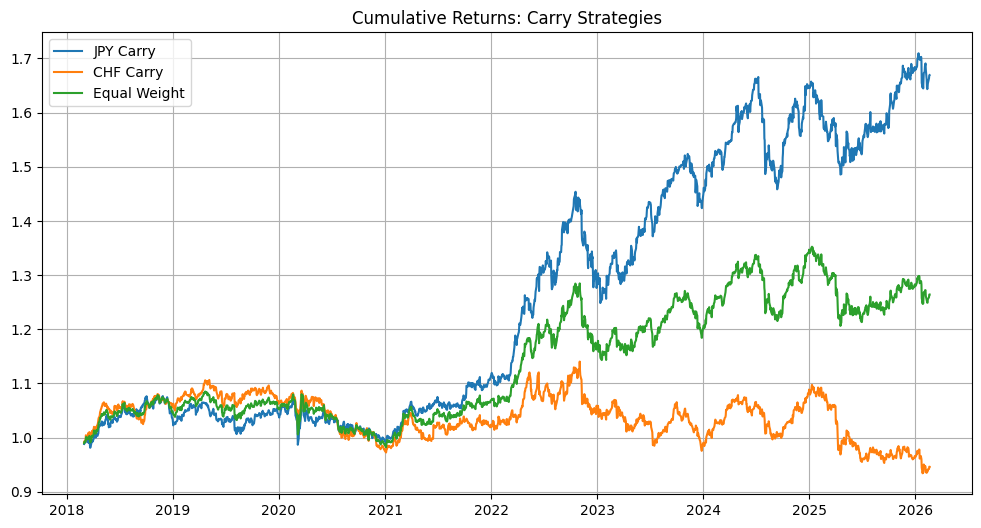

In [16]:
def cumulative(series):
    return (1 + series).cumprod()

plt.figure(figsize=(12,6))

plt.plot(cumulative(ret_jpy), label="JPY Carry")
plt.plot(cumulative(ret_chf_carry), label="CHF Carry")
plt.plot(cumulative(ret_equal_weight), label="Equal Weight")

plt.title("Cumulative Returns: Carry Strategies")
plt.legend()
plt.grid(True)
plt.show()

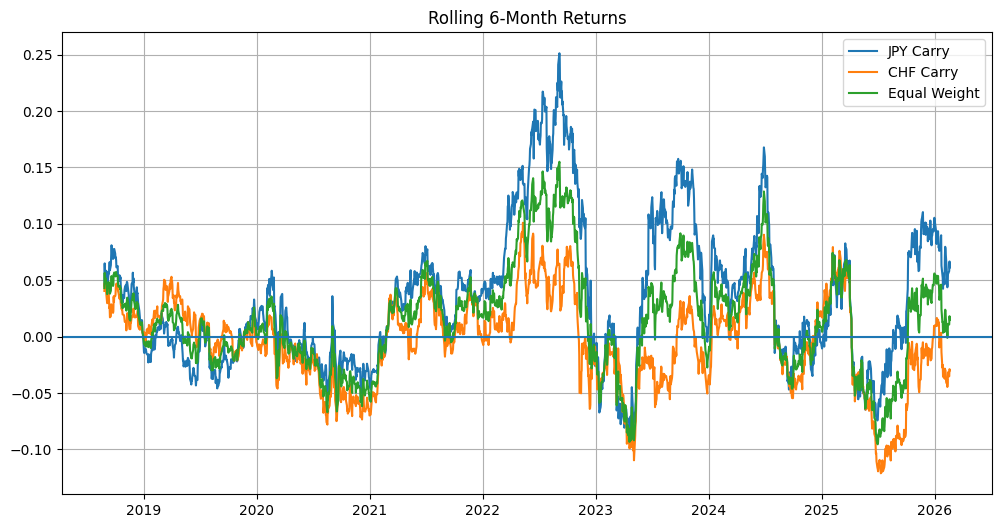

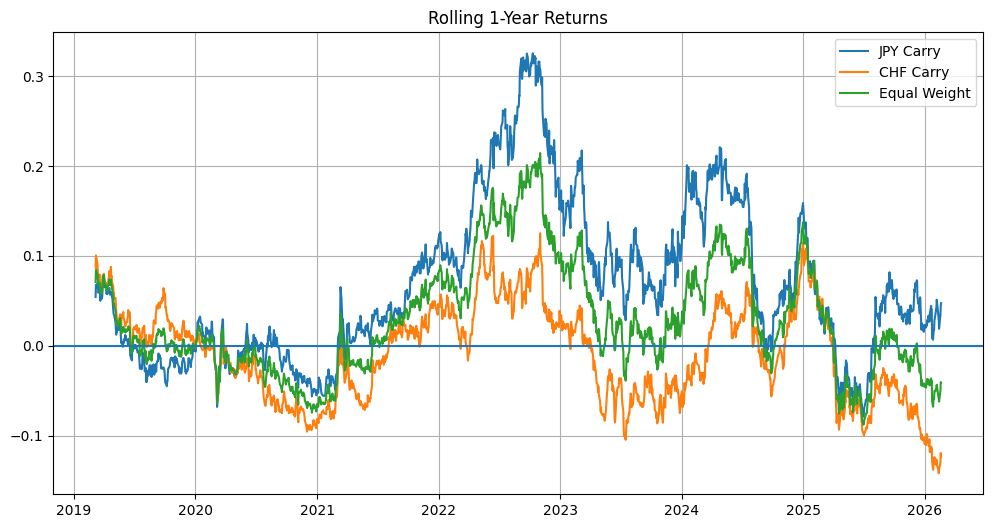

In [17]:
def rolling_return(daily_returns, window):
    return (1 + daily_returns).rolling(window).apply(np.prod, raw=True) - 1

W_6M = 126
W_1Y = 252

# --- 6 Month ---
jpy_6m = rolling_return(ret_jpy, W_6M)
chf_6m = rolling_return(ret_chf_carry, W_6M)
ew_6m  = rolling_return(ret_equal_weight, W_6M)

# --- 1 Year ---
jpy_1y = rolling_return(ret_jpy, W_1Y)
chf_1y = rolling_return(ret_chf_carry, W_1Y)
ew_1y  = rolling_return(ret_equal_weight, W_1Y)

plt.figure(figsize=(12,6))

plt.plot(jpy_6m, label="JPY Carry")
plt.plot(chf_6m, label="CHF Carry")
plt.plot(ew_6m, label="Equal Weight")

plt.axhline(0)
plt.title("Rolling 6-Month Returns")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))

plt.plot(jpy_1y, label="JPY Carry")
plt.plot(chf_1y, label="CHF Carry")
plt.plot(ew_1y, label="Equal Weight")

plt.axhline(0)
plt.title("Rolling 1-Year Returns")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
def performance_stats(daily_returns):
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol
    return ann_return, ann_vol, sharpe

strategies = {
    "JPY Carry": ret_jpy,
    "CHF Carry": ret_chf_carry,
    "Equal Weight": ret_equal_weight
}

rows = []

for name, series in strategies.items():
    ann_ret, ann_vol, sharpe = performance_stats(series)
    rows.append({
        "Strategy": name,
        "Annual Return": ann_ret,
        "Annual Volatility": ann_vol,
        "Sharpe Ratio": sharpe
    })

summary_table = pd.DataFrame(rows).set_index("Strategy").round(3)

summary_table

,Annual Return,Annual Volatility,Sharpe Ratio
Strategy,,,
JPY Carry,0.069,0.090,0.769
CHF Carry,-0.004,0.074,-0.058
Equal Weight,0.032,0.072,0.447


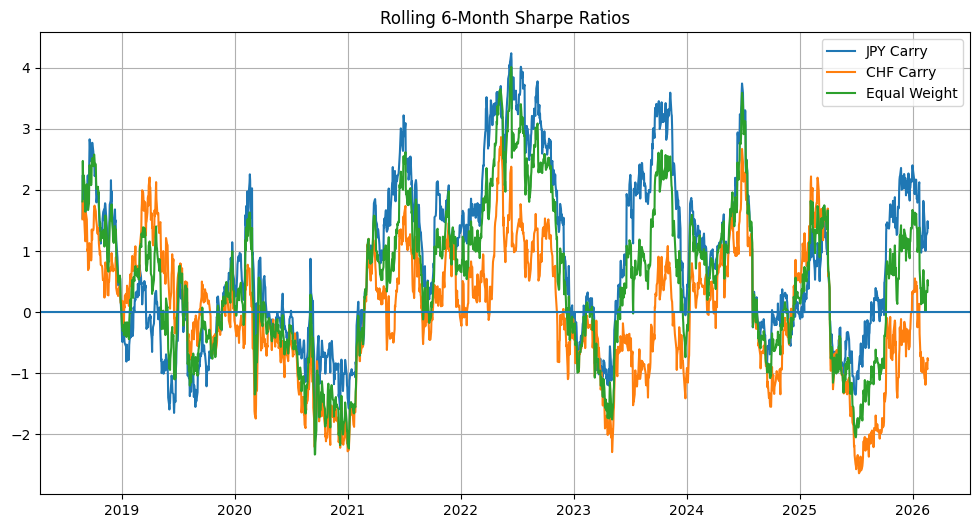

In [19]:
def rolling_sharpe(daily_returns, window=126):
    return (
        daily_returns
        .rolling(window)
        .apply(lambda x: (x.mean()/x.std())*np.sqrt(252), raw=False)
    )

plt.figure(figsize=(12,6))

plt.plot(rolling_sharpe(ret_jpy), label="JPY Carry")
plt.plot(rolling_sharpe(ret_chf_carry), label="CHF Carry")
plt.plot(rolling_sharpe(ret_equal_weight), label="Equal Weight")

plt.axhline(0)
plt.title("Rolling 6-Month Sharpe Ratios")
plt.legend()
plt.grid(True)
plt.show()

## Examining Non-equal weighted portfolios

In [31]:
lookback = 60
eps = 1e-8

df = pd.concat([ret_jpy.rename("JPY"), ret_chf_carry.rename("CHF")], axis=1).dropna()

vol = df.rolling(lookback, min_periods=lookback).std()

inv_vol = 1 / (vol + eps)
weights = inv_vol.div(inv_vol.sum(axis=1), axis=0).shift(1)

ret_vol_weighted = (weights * df).sum(axis=1).dropna()

def sharpe_ratio(daily_returns):
    return (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)

print("JPY Sharpe:", round(sharpe_ratio(ret_jpy),2))
print("CHF Sharpe:", round(sharpe_ratio(ret_chf_carry),2))
print("Equal Weight Sharpe:", round(sharpe_ratio(ret_equal_weight),2))
print("Vol-Weighted Sharpe:", round(sharpe_ratio(ret_vol_weighted),2))

JPY Sharpe: 0.77
CHF Sharpe: -0.06
Equal Weight Sharpe: 0.45
Vol-Weighted Sharpe: 0.35


In [32]:
print(ret_jpy.std(), ret_chf_carry.std())
print(ret_jpy.corr(ret_chf_carry))

0.005643268216796601 0.004634479620047502
0.5660156793968466


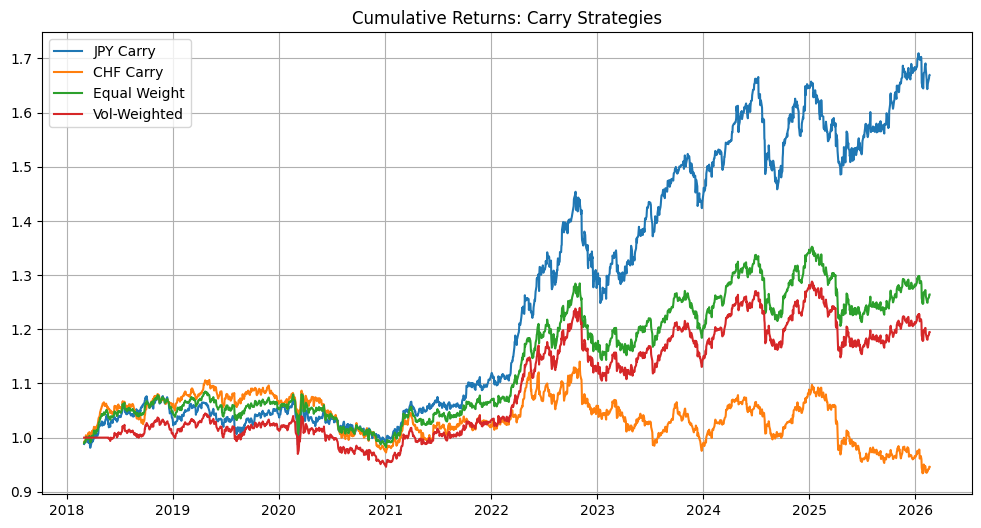

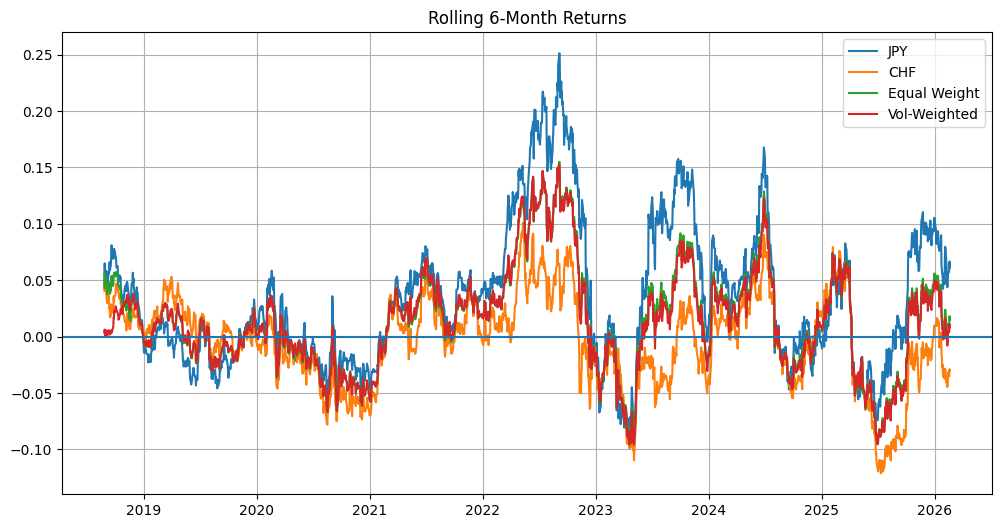

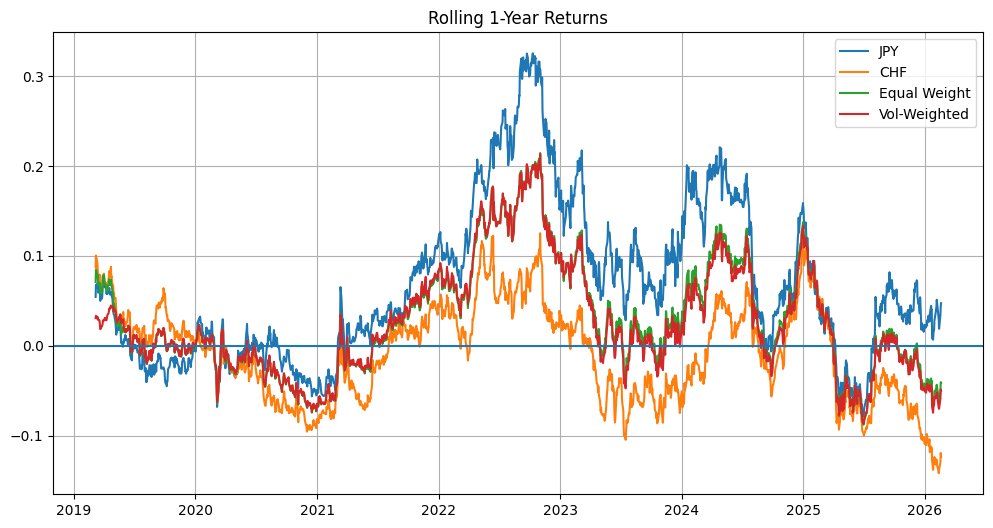

In [33]:
def cumulative(series):
    return (1 + series).cumprod()

plt.figure(figsize=(12,6))

plt.plot(cumulative(ret_jpy), label="JPY Carry")
plt.plot(cumulative(ret_chf_carry), label="CHF Carry")
plt.plot(cumulative(ret_equal_weight), label="Equal Weight")
plt.plot(cumulative(ret_vol_weighted), label="Vol-Weighted")

plt.title("Cumulative Returns: Carry Strategies")
plt.legend()
plt.grid(True)
plt.show()

def rolling_return(daily_returns, window):
    return (1 + daily_returns).rolling(window).apply(np.prod, raw=True) - 1

W_6M = 126

jpy_6m = rolling_return(ret_jpy, W_6M)
chf_6m = rolling_return(ret_chf_carry, W_6M)
ew_6m  = rolling_return(ret_equal_weight, W_6M)
vw_6m  = rolling_return(ret_vol_weighted, W_6M)

plt.figure(figsize=(12,6))

plt.plot(jpy_6m, label="JPY")
plt.plot(chf_6m, label="CHF")
plt.plot(ew_6m, label="Equal Weight")
plt.plot(vw_6m, label="Vol-Weighted")

plt.axhline(0)
plt.title("Rolling 6-Month Returns")
plt.legend()
plt.grid(True)
plt.show()


W_1Y = 252

jpy_1y = rolling_return(ret_jpy, W_1Y)
chf_1y = rolling_return(ret_chf_carry, W_1Y)
ew_1y  = rolling_return(ret_equal_weight, W_1Y)
vw_1y  = rolling_return(ret_vol_weighted, W_1Y)

plt.figure(figsize=(12,6))

plt.plot(jpy_1y, label="JPY")
plt.plot(chf_1y, label="CHF")
plt.plot(ew_1y, label="Equal Weight")
plt.plot(vw_1y, label="Vol-Weighted")

plt.axhline(0)
plt.title("Rolling 1-Year Returns")
plt.legend()
plt.grid(True)
plt.show()